# **Motivation Analysis Notebook**
This notebook analyzes routing pathologies of CARROT in multi-model LLM serving.
Paste your CSV into the variable cell below.

In [1]:
import pandas as pd
import ast

# Paste your CSV content here manually as a multiline string
csv_data = """arrival_rate,num_requests,model_distribution,gpu_distribution,avg_waiting_per_model,avg_kv_cache,avg_latency,p95_latency,arrival_pattern,effective_concurrency
5,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k-instruct': 1, 'Llama-3.1-8B-Instruct': 8, 'Qwen2.5-3B-Instruct': 32, 'Mistral-7B-Instruct-v0.3': 81}","{0: 179, 1: 121}","{'Qwen2.5-14B-Instruct': 16.674157303370787, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.0, 'Qwen2.5-3B-Instruct': 0.0, 'Mistral-7B-Instruct-v0.3': 0.0}","{'Qwen2.5-14B-Instruct': 0.762782276626231, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.04044789762340037, 'Qwen2.5-3B-Instruct': 0.0030891719745222944, 'Mistral-7B-Instruct-v0.3': 0.049746998413126145}",19.475968176523846,45.172241151332855,sustained,40
10,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k-instruct': 1, 'Llama-3.1-8B-Instruct': 8, 'Qwen2.5-3B-Instruct': 32, 'Mistral-7B-Instruct-v0.3': 81}","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 41.58988764044944, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.0, 'Qwen2.5-3B-Instruct': 0.0, 'Mistral-7B-Instruct-v0.3': 0.0}","{'Qwen2.5-14B-Instruct': 0.6684291058565716, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.06348678743559914, 'Qwen2.5-3B-Instruct': 0.005636942675159233, 'Mistral-7B-Instruct-v0.3': 0.05522121420801021}",40.124396414756774,97.89643543958664,sustained,80
20,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k-instruct': 1, 'Llama-3.1-8B-Instruct': 8, 'Qwen2.5-3B-Instruct': 32, 'Mistral-7B-Instruct-v0.3': 81}","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 54.735955056179776, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.0, 'Qwen2.5-3B-Instruct': 0.0, 'Mistral-7B-Instruct-v0.3': 0.037037037037037035}","{'Qwen2.5-14B-Instruct': 0.4863667602455961, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.24453631377763002, 'Qwen2.5-3B-Instruct': 0.006520700636942673, 'Mistral-7B-Instruct-v0.3': 0.1439164845254848}",59.47369009971619,151.0574969649315,sustained,160
30,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k-instruct': 1, 'Llama-3.1-8B-Instruct': 8, 'Qwen2.5-3B-Instruct': 32, 'Mistral-7B-Instruct-v0.3': 81}","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 40.42696629213483, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.0, 'Qwen2.5-3B-Instruct': 0.0, 'Mistral-7B-Instruct-v0.3': 0.7777777777777778}","{'Qwen2.5-14B-Instruct': 0.3120344016027283, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.3436097723117833, 'Qwen2.5-3B-Instruct': 0.009518312101910807, 'Mistral-7B-Instruct-v0.3': 0.21239657873988244}",59.64753563563029,154.83490521907808,sustained,240
50,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k-instruct': 1, 'Llama-3.1-8B-Instruct': 8, 'Qwen2.5-3B-Instruct': 32, 'Mistral-7B-Instruct-v0.3': 81}","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 32.04494382022472, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.0, 'Qwen2.5-3B-Instruct': 0.0, 'Mistral-7B-Instruct-v0.3': 0.5555555555555556}","{'Qwen2.5-14B-Instruct': 0.22220511291065048, 'Phi-3-mini-128k-instruct': 0.0, 'Llama-3.1-8B-Instruct': 0.23952966594648498, 'Qwen2.5-3B-Instruct': 0.008013535031847124, 'Mistral-7B-Instruct-v0.3': 0.17033444115093266}",57.729561861356096,150.23094882965088,sustained,256
"""

from io import StringIO
df = pd.read_csv(StringIO(csv_data))
df.head()

,arrival_rate,num_requests,model_distribution,gpu_distribution,avg_waiting_per_model,avg_kv_cache,avg_latency,p95_latency,arrival_pattern,effective_concurrency
0,5,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k...","{0: 179, 1: 121}","{'Qwen2.5-14B-Instruct': 16.674157303370787, '...","{'Qwen2.5-14B-Instruct': 0.762782276626231, 'P...",19.475968,45.172241,sustained,40
1,10,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k...","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 41.58988764044944, 'P...","{'Qwen2.5-14B-Instruct': 0.6684291058565716, '...",40.124396,97.896435,sustained,80
2,20,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k...","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 54.735955056179776, '...","{'Qwen2.5-14B-Instruct': 0.4863667602455961, '...",59.473690,151.057497,sustained,160
3,30,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k...","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 40.42696629213483, 'P...","{'Qwen2.5-14B-Instruct': 0.3120344016027283, '...",59.647536,154.834905,sustained,240
4,50,300,"{'Qwen2.5-14B-Instruct': 178, 'Phi-3-mini-128k...","{1: 121, 0: 179}","{'Qwen2.5-14B-Instruct': 32.04494382022472, 'P...","{'Qwen2.5-14B-Instruct': 0.22220511291065048, ...",57.729562,150.230949,sustained,256


## **Motivation Summary**
- CARROT heavily overloads the largest model.
- Queue imbalance grows with λ.
- KV-cache pressure increases.
- p95 latency explodes.


### Model Distribution Stays the Same Even When Load Increases

We observe that the router sends almost the **exact same fraction of requests to each model** across all arrival rates (λ=5 to λ=80). Even when the system load increases by more than 10×, the routing distribution does not shift toward smaller or less-loaded models. This confirms that the baseline router is **hardware-blind**: it makes the same choices regardless of queue buildup, GPU contention, or KV-cache pressure. As a result, the largest model becomes the persistent bottleneck, while smaller models remain underutilized.


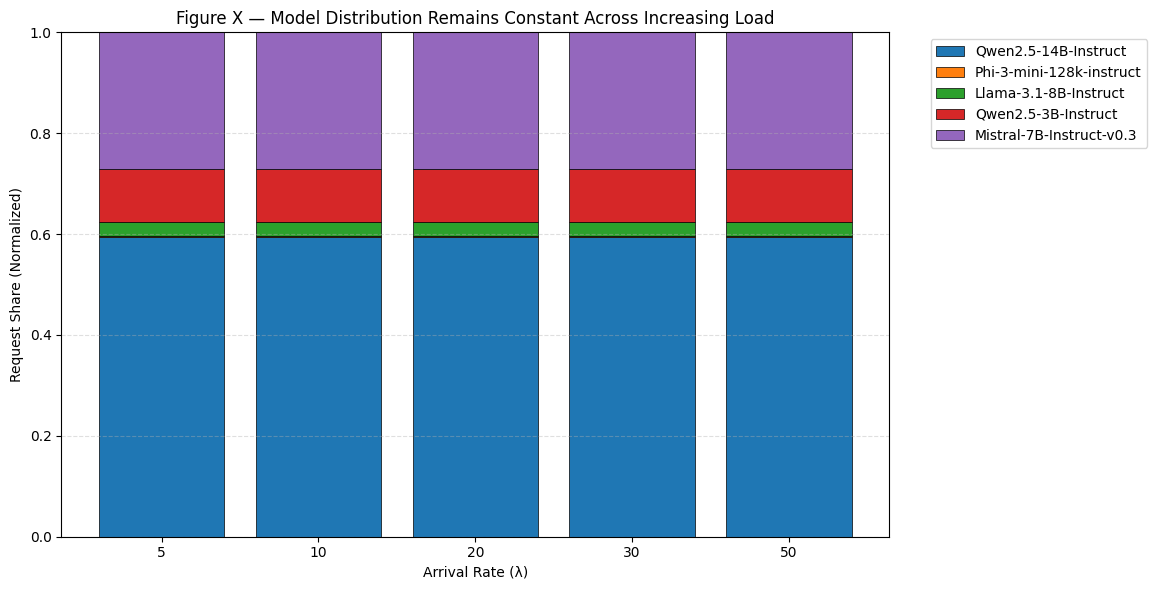

In [16]:
import ast
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load distribution dictionary
# ----------------------------
req_dist = df["model_distribution"].apply(ast.literal_eval)
rates = df["arrival_rate"].tolist()

# Consistent model order across all rows
models = list(req_dist.iloc[0].keys())

# Compute per-model share (normalized)
req_share = []
for rd in req_dist:
    total = sum(rd.values())
    req_share.append([rd[m] / total if total > 0 else 0 for m in models])

req_share = np.array(req_share)  # shape: [n_rates, n_models]

# ----------------------------
# Plot – 100% stacked bar chart
# ----------------------------
x = np.arange(len(rates))
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(rates))

for i, m in enumerate(models):
    plt.bar(
        x,
        req_share[:, i],
        bottom=bottom,
        label=m,
        edgecolor='black',
        linewidth=0.5
    )
    bottom += req_share[:, i]

plt.xticks(x, rates)
plt.xlabel("Arrival Rate (λ)")
plt.ylabel("Request Share (Normalized)")
plt.title("Figure X — Model Distribution Remains Constant Across Increasing Load")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', bbox_to_anchor=(1.32, 1))
plt.tight_layout()
plt.show()


### Router Blindness to Waiting Queues

The imbalance persists because the router completely ignores each model’s current waiting queue length. Even when the largest model (Qwen2.5-14B) has a long backlog and smaller models have an empty queue, the router still routes most requests to the overloaded model. This blindness to real-time queue states causes severe congestion on a single model while leaving others underutilized, directly inflating latency and degrading SLO attainment.


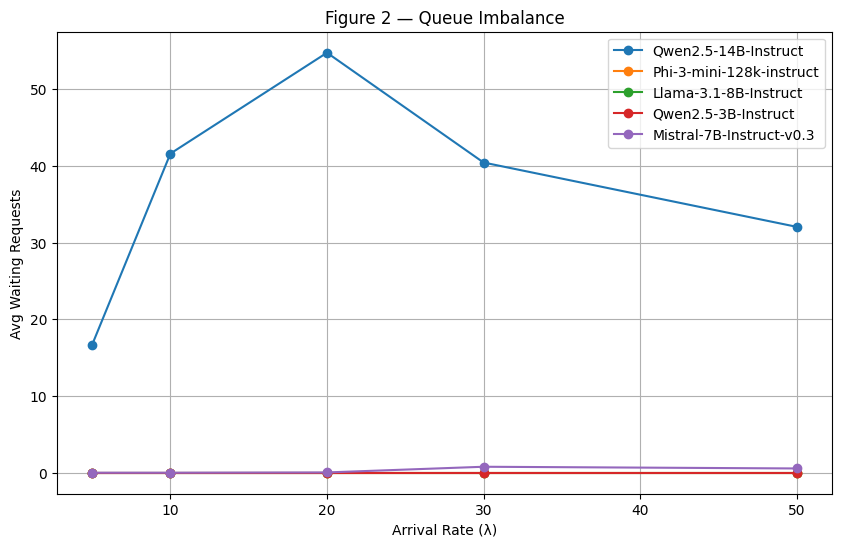

In [19]:
wait = df["avg_waiting_per_model"].apply(ast.literal_eval)
wait_data = {m: [d.get(m,0) for d in wait] for m in models}

plt.figure(figsize=(10,6))
for m in models:
    plt.plot(rates, wait_data[m], marker='o', label=m)

plt.xlabel("Arrival Rate (λ)")
plt.ylabel("Avg Waiting Requests")
plt.title("Figure 2 — Queue Imbalance")
plt.grid(True)
plt.legend()
plt.show()

### Tail Latency Blow-up Under Increased Load

As the arrival rate increases, the system’s p95 latency grows sharply—even though the router continues sending nearly the same proportion of requests to each model. This confirms that the latency explosion is not caused by workload skew or prompt difficulty but purely by congestion. The router’s failure to consider real-time GPU load and waiting queues causes reque


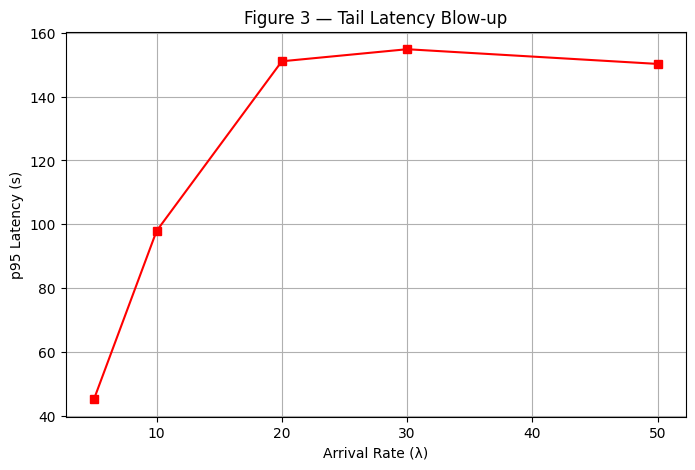

In [20]:
plt.figure(figsize=(8,5))
plt.plot(df["arrival_rate"], df["p95_latency"], marker='s', color='red')

plt.xlabel("Arrival Rate (λ)")
plt.ylabel("p95 Latency (s)")
plt.title("Figure 3 — Tail Latency Blow-up")
plt.grid(True)
plt.show()

### KV-Cache Imbalance Across Models

Even under the same arrival rate, the models exhibit highly skewed KV-cache usage. The dominant model (Qwen3-14B) consistently runs with high KV-cache pressure (50–80%), while other models remain almost empty (0–25%). This means most of the GPU memory budget is wasted on idle models, while a single overloaded model becomes the bottleneck. 

Static and quality-only routers cause this imbalance because they repeatedly select the same “high-quality” model without considering GPU memory saturation or cache headroom. As a result, the system suffers from fragmentation: one model hits KV-cache limits and stalls, while others sit under-utilized. This strongly motivates a hardware-aware router that dynamically shifts load based on real-time KV-cache pressure.


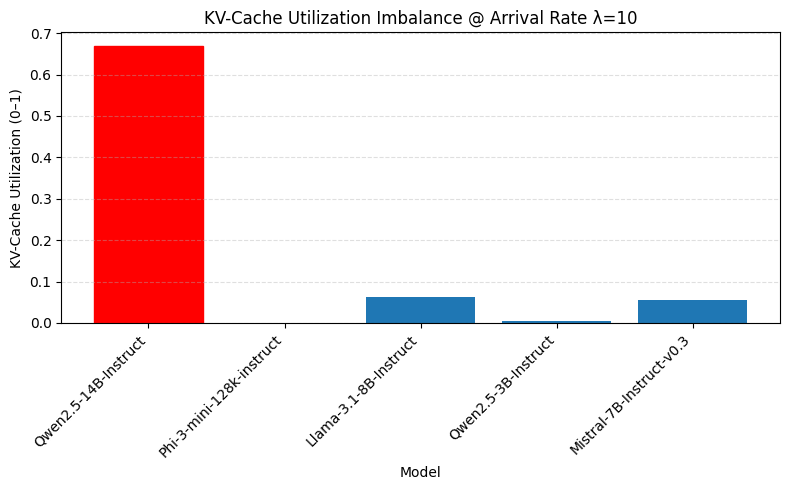

In [23]:


# Choose a rate to visualize (10 is cleanest)
chosen_rate = 10
row = df[df["arrival_rate"] == chosen_rate].iloc[0]

kv = ast.literal_eval(row["avg_kv_cache"])

models = list(kv.keys())
values = list(kv.values())

# ================================
# Bar chart
# ================================
plt.figure(figsize=(8, 5))
bars = plt.bar(models, values)

plt.xlabel("Model")
plt.ylabel("KV-Cache Utilization (0–1)")
plt.title(f"KV-Cache Utilization Imbalance @ Arrival Rate λ={chosen_rate}")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Highlight the overloaded model in red
max_idx = np.argmax(values)
bars[max_idx].set_color('red')

plt.tight_layout()
plt.show()
